# Valuation and Hedging of Options
In this project, we price and hedge European and American options using different methods.
We select Apple Inc. (AAPL) as the underlying asset and impleemnt the Black-Scholes model, Monte-Carlo simulations under Geometric Brownian Motion, and the Binomial model for American options.

All formulas are implemented manually in Python as required.

In [83]:
import numpy as np
import yfinance as yf
import pandas as pd
import math
from scipy.stats import norm
import matplotlib.pyplot as plt
import datetime

## Config

* Period: 01-01-2024 -- 01-01-2025 (1 year).
* For the risk free rate we decide to use 1Y US treasury yield at that time (approx. 4%). **Source: https://fred.stlouisfed.org/series/DGS1**
* Assume strike (K) as the mean price of the asset

In [65]:
ticker="AAPL"
df = yf.download("AAPL", start="2025-03-01", end="2026-03-01")

S=df["Close"].dropna()
r=0.04 #risk free rate (1Y )
T=1 #time to maturity (1Y)
log_returns=np.log(S/S.shift(1)).dropna()
sigma=log_returns.std()*np.sqrt(252) #annualized volatility
K=S.mean()
S0=S.iloc[-1] #current stock price



[*********************100%***********************]  1 of 1 completed


## Black-Scholes model

The Black-Scholes-Merton equation provides a framwork for option pricing. We denote the stock price as $S_t$ , $K$ be the strike price, $T$ be the time, $V$ - option price value, $r$ - risk free rate and $sigma$ - volatility(constant). The equation serves as a (foundational) tool for pricing options in continuous time, it is universally use to determine fair value of **European options**, including calls and puts, on various underlying assets like stocks, indices, and commodities.

The model assumes:
- Lognormal distribution of prices
- Constant volatility
- Constant risk-free rate
- No dividends
- No arbitrage
- Continuous time

Black-Scholes equation:

$\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S_t^2 \frac{\partial^2 V}{\partial S_t^2} + rS_t \frac{\partial V}{\partial S_t} - rV = 0, \quad with \quad 0<S_t<S_T, \quad 0 \leq t<T$

The PDE is derived from no arbitrage principle, which states that it is impossible to make a risk free profit from a set of options and underlying asset. The Black Scholes PDE cgives the expected value of the discounted payoff of the option at any earlier time, this is the risk-neutral valuation approach, which can be dont without knowledge of PDEs.

### Closed formula implementation
Intuition and conception:
- Investors buy call options if they anticipate that the underlying asset price will rise.
- Investors buy put  when they anticipate that the underlying asset's price will decrease.

Call Price:

$$C = S_0 \cdot N(d_1) - K \cdot e^{-rT} \cdot N(d_2)$$

Put Price:

$$P = K \cdot e^{-rT} \cdot N(d_2) - S \cdot N(-d1)$$

In [66]:
#helpers
def d1(S, K, r, sigma, T):
    return (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))

def d2(S, K, r, sigma, T):
    return d1(S,K,r,sigma,T) - sigma*np.sqrt(T)

In [177]:
N= norm.cdf

def black_scholes_call(S, K, r, sigma, T):
    return S*N(d1(S,K,r,sigma,T)) - K*np.exp(-r*T)*N(d2(S,K,r,sigma,T))

def black_scholes_put(S, K, r, sigma, T):
    return K*np.exp(-r*T)*N(-d2(S,K,r,sigma,T)) - S*N(-d1(S,K,r,sigma,T))

In [180]:
call_price=float(black_scholes_call(S0, K, r, sigma, T).iloc[0])

put_price=float(black_scholes_put(S0, K, r, sigma, T).iloc[0])

call_price, put_price

(32.35523470881769, 26.557542540118348)

### Put via Put-Call Parity + Payoff +PnL
Using put-call parity:

$$P = C - S_0 + K \cdot e^{-rT}$$

- **Payoff** = $Max(K-S_T, 0)$
- **PnL** = $Payoff - P$

Key levels:
- Breakeven: $S_T = K - P$
- Max profit: $K - P  \quad (if \quad S_T →  0)$
- Max loss: $-P        \quad (if \quad S_T≥ K)$

In [183]:
P=call_price - S0 + K*np.exp(-r*T)
P

Ticker
AAPL    26.557543
dtype: float64

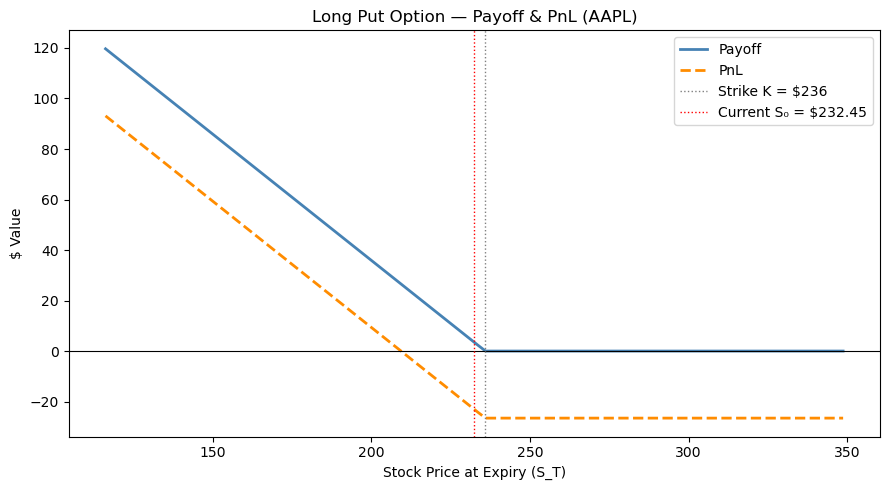

In [184]:
#Evaluate payoff and PnL at different stock prices at maturity
ST=np.linspace(0.5*float(S0.iloc[0]), 1.5*float(S0.iloc[0]), 100)
payoffs=np.maximum(float(K.iloc[0])-ST,0)
pnl=payoffs - float(P.iloc[0])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ST, payoffs, label="Payoff", linewidth=2, color="steelblue")
ax.plot(ST, pnl,    label="PnL",    linewidth=2, color="darkorange", linestyle="--")
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(float(K.iloc[0]), color="gray", linewidth=1, linestyle=":", label=f"Strike K = ${float(K.iloc[0]):.0f}")
ax.axvline(float(S0.iloc[0]), color="red", linewidth=1, linestyle=":",
           label=f"Current S₀ = ${float(S0.iloc[0]):.2f}")
ax.set_xlabel("Stock Price at Expiry (S_T)")
ax.set_ylabel("$ Value")
ax.set_title("Long Put Option — Payoff & PnL (AAPL)")
ax.legend()
plt.tight_layout()
plt.show()

The put is currently in-the-money since S0 < K. The buyer of the put profits only if AAPL falls below the breakeven(K-P). The Maximum loss is capped at the premium paid (P), while the maximum gain is K-P (if stock goes to zero). This asymmetric risk profile is the key advantage of buying put options for downside protection.

## Greeks

Greeks are vital tools in risk management, it represents the first-order sensitivities of option price to changes in one underlying parameter.

(Assuming for Vega, 2.5% increase in volatility, for Rho, 1.4% increase in the risk-free rate.)

| Greek | Formula | Definition |
| --- | --- | --- |
| Delta | $\Delta = N(d_1)$ | sensitivity to underlying price |
| Gamma | $\Gamma = \frac{N'(d_1)}{S_0 \sigma \sqrt{T}}$ | sensitivity of Delta |
| Theta (daily) | $\Theta = \frac{-S_0 N'(d_1)\sigma}{2\sqrt{T}} - rKe^{-rT}N(d_2)$, then divide by 252 | time decay |
| Vega | $\mathcal{V} = S_0 \sqrt{T} N'(d_1)$, then multiply by 0.025 | sensitivity to volatility |
| Rho | $\rho = KTe^{-rT}N(d_2)$, then multiply by 0.014 | sensitivity to interest rates |

where $N'(x) = \frac{1}{\sqrt{2\pi}}e^{-x^2/2}$ (standard normal PDF).



In [127]:
delta=N(d1(S0,K,r,sigma,T))
delta

array([0.59462515])

if AAPL increases by $1, the call price increases by approximately $0.59

**Deeper interpretation and for delta hedging:**
- Delta is between 0 and 1 for a call.
- Deep ITM call => Delta = 1
- Deep OTM call => Delta = 0
- ATM call => Delta = 0.5

Delta also represents number of shares needed to hedge one call.

In [128]:
gamma = norm.pdf(d1(S0,K,r,sigma,T)) / (S0*sigma*np.sqrt(T))
gamma

Ticker
AAPL    0.005178
dtype: float64

if AAPL increases by $1, Delta increases by 0.0052.

**Deeper interpretation:**
- High Gamma => Delta unstable
- Gamma highest near ATM
- Gamma always positive for calls and puts.

Delta also represents the curvature of the option value and reflects how sensitive the delta is to changes in the underlying price.

In [129]:
theta = (-S0*norm.pdf(d1(S0,K,r,sigma,T))*sigma/(2*np.sqrt(T))
         - r*K*np.exp(-r*T)*norm.cdf(d2(S0,K,r,sigma,T))) / 252
theta

Ticker
AAPL   -0.074388
dtype: float64

The option loses approximately $0.07 per day, all else equal.

**Deeper interpretation:**
- Calls usually have negative theta
- Time decay accelerates near maturity
- ATM options lose value fastest.

Theta captures the cost of time passing. For long options, time decay represents a systematic loss of calue as maturity approaches.

In [130]:
vega = S0 * norm.pdf(d1(S0,K,r,sigma,T)) * np.sqrt(T)
vega_impact = vega * 0.025
vega_impact

Ticker
AAPL    2.252808
Name: 2026-02-27 00:00:00, dtype: float64

if volatility increases by 2.5%, the call price increases by approximately $2.25.

**Deeper interpretation:**
- Vega highest for ATM options.
- Long calls benefit from volatility increases.


Vega reflects the sensitivity of the option price to changes in expected volatility. Long options are long volatility.

In [131]:
rho = K*T*np.exp(-r*T)*norm.cdf(d2(S0,K,r,sigma,T))
rho_impact = rho * 0.014
rho_impact

Ticker
AAPL    1.482097
dtype: float64

if interest rates increase by 1.4%, the call price increases by approximately $1.48.

**Deeper interpretation:**
- Calls benefit from higher interest rates
- Puts lose value when rates rise

Why? Because higher rates reduce the present value of the strike

### **Insights:**
Greeks are local derivatives. They are only valid for small changes in their respective parameters. Afterall, it is linear approximations. In case of large moves, there are presence of non-linear effects, in this case, Gamma matters.

# Implied Volatility

Implied volatility reflects investors' perceptions of uncertainty or risk associated with the future movements of the underlying asset. Since volatility is the only parameter which is unobserved in Black-Scholes framework, it is important to grasp as it can be used to project future moves of option price. It can often be thought to be a proxy of market risk.

We often refer to the volatility smile, as it is related to the fact that options at different strikes have different levels of implied volatility. Graphing IV against strike prices for a given maturity produce a skewed "smile" instead of a flat surface.

IV is a good indicator to quantify market sentiment:
- IV generally increases in bearish markets, when investors believe prices will decline over time.
- IV decreases when in bullish market.

In quantitative finance, modeling the volatility smile is an active area of research, and better pricing models such as the stochastic volatility model partially address this issue.

A related concept is the term structure of volatility, which describes how IV differs for related options with different maturities. An IV surface is a 3-D plot that plots volatility smile and term structure of volatility in a consolidated three-dimensional surface for all options on a give underlying asset.

In [185]:
aapl=yf.Ticker("AAPL")

#available option expiries
expiries=aapl.options
print("Available Expiries:", expiries)

Available Expiries: ('2026-03-04', '2026-03-06', '2026-03-09', '2026-03-11', '2026-03-13', '2026-03-20', '2026-03-27', '2026-04-02', '2026-04-10', '2026-04-17', '2026-05-15', '2026-06-18', '2026-07-17', '2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15', '2027-03-19', '2027-06-17', '2027-12-17', '2028-01-21', '2028-03-17', '2028-12-15')


In [188]:
AS_OF_DATE = datetime.date(2026, 1, 1)
end_date=AS_OF_DATE.strftime("%Y-%m-%d")
start_date=(AS_OF_DATE - datetime.timedelta(days=30)).strftime("%Y-%m-%d")

target=AS_OF_DATE.replace(year=AS_OF_DATE.year + 1) #target 1Y expiry

expiries_dt = [datetime.datetime.strptime(e, "%Y-%m-%d").date() for e in expiries]

best_expiry = min(expiries_dt, key=lambda x: abs(x - target))
expiry_str = best_expiry.strftime("%Y-%m-%d")

T_market = (best_expiry - AS_OF_DATE).days / 365

print(f"Option expiry: {expiry_str} (T = {T_market:.4f} yrs)")

Option expiry: 2026-12-18 (T = 0.9616 yrs)


In [189]:
chain=aapl.option_chain(expiry_str)
calls=chain.calls
puts=chain.puts

#strike closest to K
call_row=calls.iloc[(calls["strike"]-K).abs().argsort()[:1]]
put_row=puts.iloc[(puts["strike"]-K).abs().argsort()[:1]]

K_call=float(call_row["strike"].values[0])
K_put=float(put_row["strike"].values[0])

call_market=float((call_row["bid"].values[0] + call_row["ask"].values[0]) / 2)
put_market=float((put_row["bid"].values[0] + put_row["ask"].values[0]) / 2)

print(f"\nCall: strike=${K_call:.2f},  mid-price=${call_market:.4f}")
print(f"Put:  strike=${K_put:.2f},  mid-price=${put_market:.4f}")


Call: strike=$530.00,  mid-price=$0.1100
Put:  strike=$460.00,  mid-price=$201.7500


C:\Users\khanh\AppData\Local\Temp\ipykernel_16296\2501363365.py:6: FutureWarning: The behavior of Series.argsort in the presence of NA values is deprecated. In a future version, NA values will be ordered last instead of set to -1.
  call_row=calls.iloc[(calls["strike"]-K).abs().argsort()[:1]]
C:\Users\khanh\AppData\Local\Temp\ipykernel_16296\2501363365.py:7: FutureWarning: The behavior of Series.argsort in the presence of NA values is deprecated. In a future version, NA values will be ordered last instead of set to -1.
  put_row=puts.iloc[(puts["strike"]-K).abs().argsort()[:1]]


## First method: Brute Force

In [190]:
def implied_vol_brute(market_price, S, K, r, T, option_type="call", step=0.0001, max_sigma=5):
    """Brute-force search for implied volatility."""
    #track the best sigma (minimum difference)
    best_sigma = None
    best_diff = float('inf')
    sigma=step

    while sigma < max_sigma:
        if option_type == "call":
            price = float(black_scholes_call(S, K, r, sigma, T).iloc[0])
        else:
            price = float(black_scholes_put(S, K, r, sigma, T).iloc[0])

        diff=abs(price - market_price)
        if diff < best_diff:
            best_diff = diff
            best_sigma = sigma

        #BS call price is monotonically increasing in sigma, so we can stop once we start getting higher prices than market
        if price > market_price:
            break
    
        sigma += step
    return best_sigma  # If no solution found within range

iv_call_brute=implied_vol_brute(call_market, S0, K_call, r, T_market, option_type="call")
iv_put_brute=implied_vol_brute(put_market, S0, K_put, r, T_market, option_type="put")

print(f"Brute force IV call: {iv_call_brute:.4f}")
print(f"Brute force IV put: {iv_put_brute:.4f}")

Brute force IV call: 0.2981
Brute force IV put: 0.0001


In [191]:
#replug to check if we get close to market price
call_price_replug=float(black_scholes_call(S0, K_call, r, iv_call_brute, T_market).iloc[0])
put_price_replug=float(black_scholes_put(S0, K_put, r, iv_put_brute, T_market).iloc[0])

print(f"\nReplug call price: ${call_price_replug:.4f} (market: ${call_market:.4f})")
print(f"Replug put price: ${put_price_replug:.4f} (market: ${put_market:.4f})")


Replug call price: $0.1100 (market: $0.1100)
Replug put price: $210.1940 (market: $201.7500)


key insight: BS option price is monotonically increasing in sigma, so there's exactly one sigma where price = market price. We just find the sigma that gets closest.

## Newton Raphson Algorithm
The Newton Raphson method is a widely used algorithm for calculating the implied volatility of an option. The steps for the generic algorithm are as follows:

1. Define our function as $f(x)$ for which we want to solve $f(x)=0$
2. Choose an initial guess
3. Iterate as follows: $x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$
4. Break if: $|f(x_n)| <\epsilon$, here $\epsilon$ is the tolerance for error describes in the brute force method

Applying the staps above to our problem of solving implied volatility:
1. $f(\sigma) = V_{BS_\sigma} - V_{market}$
2. Initial guess $\sigma_0 = 0.05$ (chosen for convenience)
3. $\sigma_{n+1} = \sigma_n - \frac{V_{BS} - V_{\text{market}}}{\frac{\partial V_{BS_{\sigma}}}{\partial \sigma}}$
4. $|V_{BS} - V_{market}| <\epsilon$, return $\sigma_n$

In order to code this in Python we first need to make a function that computes the partial derivative of the value of a call option with respect to volatility. This partial derivative is commonly referred to as vega. 

$vega = S \sqrt{T}\Phi'(d1)$

Please note that $d1$ in $vega$ is the same $d_{1}=\frac{\ln \frac{S_{t}}{K} + (r + \frac{\sigma^2}{2})\tau}{\sigma\sqrt{\tau}}$ that we calculated in the Black-Scholes formula and $\Phi'$ is the probability density function for a standard normal distribution

In [192]:
def vega(S,K,r,sigma,T):
    return S * norm.pdf(d1(S,K,r,sigma,T)) * np.sqrt(T)

Now that we have a function to calculate vega, let's create a function to implement Newton's method on our case and compare it to the value we got with brute force

In [193]:
def implied_vol_newton(market_price, S, K, r, T, option_type="call", tol=1e-6, max_iter=1000):
    """Newton-Raphson method for implied volatility."""
    sigma = 0.2  # Initial guess
    for i in range(max_iter):
        if option_type == "call":
            price = float(black_scholes_call(S, K, r, sigma, T).iloc[0])
        else:
            price = float(black_scholes_put(S, K, r, sigma, T).iloc[0])

        diff=price - market_price

        if abs(diff) < tol:
            print(f"found on {i}th iteration")
            print(f"difference is equal to {diff}")
            return sigma
        
        if abs(vega(S,K,r,sigma,T).iloc[0]) < 1e-8:  # Avoid division by zero
            print("Vega is too small, stopping iteration.")
            break

        sigma-=diff/float(vega(S,K,r,sigma,T).iloc[0])
        
    return sigma

In [194]:
iv_call_nr=implied_vol_newton(call_market, S0, K_call, r, T_market, option_type="call")
iv_put_nr=implied_vol_newton(put_market, S0, K_put, r, T_market, option_type="put")

print(f"\nNewton-Raphson IV call: {iv_call_nr:.4f}")
print(f"Newton-Raphson IV put: {iv_put_nr:.4f}")

Vega is too small, stopping iteration.
Vega is too small, stopping iteration.

Newton-Raphson IV call: -20638.6889
Newton-Raphson IV put: -14.6740


In [195]:
#recheck replug with Newton-Raphson IV
call_price_replug_nr=float(black_scholes_call(S0, K_call, r, iv_call_nr, T_market).iloc[0])
put_price_replug_nr=float(black_scholes_put(S0, K_put, r, iv_put_nr, T_market).iloc[0])

print(f"\nReplug call price (NR IV): ${call_price_replug_nr:.4f} (market: ${call_market:.4f})")
print(f"Replug put price (NR IV): ${put_price_replug_nr:.4f} (market: ${put_market:.4f})")


Replug call price (NR IV): $-510.0003 (market: $0.1100)
Replug put price (NR IV): $-232.4478 (market: $201.7500)


Compare between two methods, we find it effectively identical. Whilst the brute force method works pretty well, it takes quite a while for brute force to finish, imagine having 1000 options to calculate implied volatility. It tooks roughly 6 seconds for the above script to finish, multiplying that by 1000 equates to well over an hourt of waiting.

Regarding Newton-Raphson method, one problem is when the vega will be close to zero which is the case if the option is considered as out of the money options.

# GBM and Monte Carlo implementation

What is a "Brownian Motion"?

It is a stochastic (=random) process used to describe the random movement of an object in a medium (gas, liquid).

What is a "Geometric Brownian motion" ?

Geometric Brownian motion (GBM) also known as an exponential Brownain motion, is a continuous time stochastic process in which the logarithm of the randomly varying quantity follows a brownian motion with drift. It is an important example of stochastic processes satisfying a stochastic differential equation (SDE); in particular, it is used in mathematical finance to model stock prices (in Black-Scholes framework).

SDE:
$$dS_t = \mu S_t , dt + \sigma S_t , dW_t$$

where $W_t$ is a Wiener process. This equation is nos in the form of an Ito process.

Ito's Lemma in short, states if a random variable follows an Ito Process (example above) then another twice differentiable function $G$ described by the stock price $S$ and time $t$ also follows at Ito process:

$dG(t, x) = \left( \frac{\partial G}{\partial S} S \mu + \frac{\partial G}{\partial t} + \frac{1}{2} \frac{\partial^2 G}{\partial S^2} S^2 \sigma^2 \right) dt + \frac{\partial G}{\partial S} S \sigma dW_t$

We could apply the Ito's lemma to $G = S$ in order to obtain arithmetic Brownian motion, howver using $G = ln(S)$ which gives a nice property that the stock price is strictly greater than 0. So applying Ito's lemma to $ln(S)$, we can based on Euler-Maruyama work.

Discretized (Euler-Maruyama):
$$S_{t+\Delta t} = S_t \cdot \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t} \cdot Z\right], \quad Z \sim N(0,1)$$

In [122]:
def mc_call_gbm(S0, K, r, sigma, T, n_sims=20000, n_steps=252):
    # Ensure all inputs are plain floats
    S0, K, r, sigma, T = float(S0), float(K), float(r), float(sigma), float(T)
    
    dt = T / n_steps
    payoffs = []
    for _ in range(n_sims):
        S = S0
        for _ in range(n_steps):
            Z = np.random.standard_normal()
            S *= np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
        payoffs.append(max(S - K, 0))
    return np.exp(-r * T) * np.mean(payoffs)

np.random.seed(42)  # For reproducibility
mc_price=mc_call_gbm(S0, K_call, r, sigma, T_market)
print(f"\nMonte Carlo call price: ${mc_price:.4f} (BS price: ${call_price:.4f})")

C:\Users\khanh\AppData\Local\Temp\ipykernel_16296\1572377177.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0, K, r, sigma, T = float(S0), float(K), float(r), float(sigma), float(T)


TypeError: unsupported format string passed to Series.__format__